# Gait Recognition with WiFi

Yi Zhang, Yue Zheng, Guidong Zhang, Kun Qian, Chen Qian, Zheng Yang. 2020. "GaitID: Robust Wi-Fi Based Gait Recognition". In Proceedings of International Conference on Wireless Algorithms, Systems, and Applications (WASA'2020). Lecture Notes in Computer Science, vol 12384. Springer, Cham.

Can be download within the Widar3.0 homepage.

## Introduction

File Name Format：
- id-a-b-Rx.dat
- 'id': user's id; 'a': track no., 'b': repetition no., 'Rx': Wi-Fi receiver id.


| Room #  | ID    | Date     | Instances |
|---------|-------|----------|-----------|
| Room #1 | user1 | 20190627 | 4*100     |
| Room #1 | user2 | 20190627 | 4*100     |
| Room #1 | user3 | 20190706 | 4*100     |
| Room #1 | user4 | 20190707 | 4*100     |
| Room #1 | user5 | 20190713 | 4*100     |
| Room #1 | user6 | 20190713 | 4*100     |
| Room #1 | user7 | 20190713 | 4*100     |
| Room #1 | user8 | 20190718 | 4*50      |
| Room #1 | user9 | 20190718 | 4*50      |
| Room #1 | user10| 20190719 | 4*50      |
| Room #2 | user11| 20190719 | 4*50      |
| Room #2 | user1 | 20190719 | 4*20      |
| Room #2 | user2 | 20190719 | 4*20      |


Downloaded files:

```shell
.
├── 20190627.zip
├── 20190706_sup.zip
├── 20190706.zip
├── 20190707_sup.zip
├── 20190707.zip
├── 20190713.zip
├── 20190718.zip
├── 20190719.zip
├── READ.ipynb
└── README_Gait.pdf      # the official document of the dataset
```

After unzipping the files and the merge the _sup folders into the corresponding folders, the directory structure is as follows:

```shell
.
├── 20190627
├── 20190706
├── 20190707
├── 20190713
├── 20190718
├── 20190719
└── README_Gait.pdf
```

<font color='red'>**Note:**</font> We later pack the data into a single folder (CSI) for easy access. And use save_preprocessed_csi.py to generate the preprocessed data and the dfs data, all stored in the CSI-Processed and DFS folders.



## Preprocessing

#### make a meta information file for later use

conains: file name + user id + track no. + repetition no. + receiver id (a pickle file)

In [1]:
# # list all the folder names in current directory
# import os
# import sys

# Date_foders = ['20190707', '20190718', '20190713', '20190706', '20190627', '20190719']

# Date_user ={}

# def list_folders(folder_path):
#     folders = []
#     for f in os.listdir(folder_path):
#         if os.path.isdir(os.path.join(folder_path, f)):
#             folders.append(f)
#     return folders

# for fo in Date_foders:
#     Date_user[fo] = list_folders(fo)

# for k, v in Date_user.items():
#     print(k, v)

In [2]:
# folder_list = []

# for fo in Date_user.keys():
#     f_name = Date_user[fo]
#     for f in f_name:
#         ffff = os.path.join(fo, f) 
#         if not os.path.exists(ffff):
#             print(f'{ffff} does not exist')
#         else:
#             print(f'{ffff} exists')
#             folder_list.append(ffff)
        

In [3]:
# # id-a-b-Rx.dat
# # 'id': user's id; 'a': track no., 'b': repetition no., 'Rx': Wi-Fi receiver id.

# def parse_name(name):
#     name = name.split('-')
#     id = int(name[0][4:])
#     track = int(name[1])
#     rep = int(name[2])
#     rx =int(name[3].split('.')[0][1:])
#     return id, track, rep, rx

# file_names = []
# user_ids = []
# track_ids = []
# rep_ids = []
# rx_ids = []

# for folder_n in folder_list:
#     files = os.listdir(folder_n)
#     for f in files:
#         if f.endswith('.dat'):
#             file_path = os.path.join(folder_n, f)
#             file_names.append(file_path)
#             id, track, rep, rx = parse_name(f)
#             user_ids.append(id)
#             track_ids.append(track)
#             rep_ids.append(rep)
#             rx_ids.append(rx)

In [4]:
# # save files_names, user_ids, track_ids, rep_ids, rx_ids as csv files
# import pandas as pd
# df = pd.DataFrame({'file_name': file_names, 'user_id': user_ids, 'track_id': track_ids, 'rep_id': rep_ids, 'rx_id': rx_ids})
# df.to_csv('metas.csv', index=False)
# print('metas.csv is saved')


### loading data

In [5]:
# load the metas.csv file
import pandas as pd
df = pd.read_csv('metas.csv')
print(df.head())


                          file_name  user_id  track_id  rep_id  rx_id
0   20190707/user1/user1-5-3-r5.dat        1         5       3      5
1  20190707/user1/user1-5-12-r1.dat        1         5      12      1
2  20190707/user1/user1-6-13-r3.dat        1         6      13      3
3   20190707/user1/user1-6-9-r6.dat        1         6       9      6
4   20190707/user1/user1-6-2-r6.dat        1         6       2      6


In [6]:
file_names = df['file_name'].values
user_ids = df['user_id'].values
track_ids = df['track_id'].values
rep_ids = df['rep_id'].values
receiver_ids = df['rx_id'].values

print(len(file_names), len(user_ids), len(track_ids), len(rep_ids), len(receiver_ids))
print('user ids: ',set(user_ids))
print('track ids: ',set(track_ids))
print('rep ids: ',set(rep_ids))
print('receiver ids: ',set(receiver_ids))

22528 22528 22528 22528 22528
user ids:  {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
track ids:  {1, 2, 3, 4, 5, 6}
rep ids:  {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}
receiver ids:  {1, 2, 3, 4, 5, 6}


In [7]:

import numpy as np

select_user_id = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
select_track_id = [1, 2, 3, 4, 5, 6] 
select_receiver_id = [6]

select_file_index = []

for i in range(len(user_ids)):
    if user_ids[i] in select_user_id and track_ids[i] in select_track_id and receiver_ids[i] in select_receiver_id:
        select_file_index.append(i)

print('number of selected files: ', len(select_file_index))

number of selected files:  3752


In [8]:
fn =file_names[select_file_index[20]]
print(fn)

20190707/user1/user1-5-14-r6.dat


In [9]:
from CSIKit.reader import IWLBeamformReader

my_reader = IWLBeamformReader()
csi_data = my_reader.read_file(fn)
print(type(csi_data))

frames = csi_data.frames
csi_shape = frames[0].csi_matrix.shape
print("csi_shape: ", csi_shape)
print("csi_matrix[21,1,0]: ", frames[0].csi_matrix[21,1,0])

<class 'CSIKit.csi.csidata.CSIData'>
csi_shape:  (30, 3, 1)
csi_matrix[21,1,0]:  (-9+1j)


In [10]:
meta_data = csi_data.get_metadata()

# the meta_data is a CSIMetadata object, print all the attributes
print("chipset: ", meta_data.chipset)
print("backend: ", meta_data.backend)
print("bandwidth: ", meta_data.bandwidth)
print("antenna_config: ", meta_data.antenna_config)
print("frames: ", meta_data.frames)
print("subcarriers: ", meta_data.subcarriers)
print("time_length: ", meta_data.time_length)
print("average_sample_rate: ", meta_data.average_sample_rate)
print("average_rssi: ", meta_data.average_rssi)
print("csi_shape: ", meta_data.csi_shape)


chipset:  Intel IWL5300
backend:  Linux 802.11n CSI Tool
bandwidth:  20
antenna_config:  3 Rx, 1 Tx
frames:  8143
subcarriers:  30
time_length:  8.146009999999933
average_sample_rate:  999.6
average_rssi:  36.3
csi_shape:  (30, 3, 1)


In [7]:
import itertools
from typing import Tuple
import numpy as np

def get_CSI(csi_data: 'CSIData', squeeze_output: bool = False) -> Tuple[np.array, int, int]:
    frames = csi_data.frames
    csi_shape = frames[0].csi_matrix.shape

    no_frames = len(frames)
    no_subcarriers = csi_shape[0]

    # Matrices should be Frames * Subcarriers * Rx * Tx.
    # Single Rx/Tx streams should be squeezed.
    if len(csi_shape) == 3:
        # Intel data comes as Subcarriers * Rx * Tx.
        no_rx_antennas = csi_shape[1]
        no_tx_antennas = csi_shape[2]
    elif len(csi_shape) == 2 or len(csi_shape) == 1:
        # Single antenna stream.
        no_rx_antennas = 1
        no_tx_antennas = 1
    else:
        # Error. Unknown CSI shape.
        print("Error: Unknown CSI shape.")

    csi = np.zeros((no_frames, no_subcarriers, no_rx_antennas, no_tx_antennas), dtype=complex)
    ranges = itertools.product(*[range(n) for n in [no_frames, no_subcarriers, no_rx_antennas, no_tx_antennas]])
    is_single_antenna = no_rx_antennas == 1 and no_tx_antennas == 1

    drop_indices = []
    for frame, subcarrier, rx_antenna_index, tx_antenna_index in ranges:
        frame_data = frames[frame].csi_matrix
        if subcarrier >= frame_data.shape[0]:
            # Inhomogenous component
            # Skip frame for now. Need a better method soon.
            continue

        subcarrier_data = frame_data[subcarrier]
        if subcarrier_data.shape != (no_rx_antennas, no_tx_antennas) and not is_single_antenna:
            if rx_antenna_index >= subcarrier_data.shape[0] or tx_antenna_index >= subcarrier_data.shape[1]:
                # Inhomogenous component
                # Skip frame for now. Need a better method soon.
                drop_indices.append(frame)
                continue
        csi[frame][subcarrier][rx_antenna_index][tx_antenna_index] = subcarrier_data if is_single_antenna else \
            subcarrier_data[rx_antenna_index][tx_antenna_index]  
    csi = np.delete(csi, drop_indices, 0)
    csi_data.timestamps = [x for i, x in enumerate(csi_data.timestamps) if i not in drop_indices]
    if squeeze_output:
        csi = np.squeeze(csi)
    return (csi, no_frames, no_subcarriers)


csi_matrix1, no_frames1, no_subcarriers1 = get_CSI(csi_data)
print("csi_matrix: ", csi_matrix1.shape)
print('one element in csi_matrix: ', csi_matrix1[0][0][0])
print("no_frames: ", no_frames1)
print("no_subcarriers: ", no_subcarriers1)

csi_matrix:  (9003, 30, 3, 1)
one element in csi_matrix:  [-9.-9.j]
no_frames:  9003
no_subcarriers:  30


(47+4j)


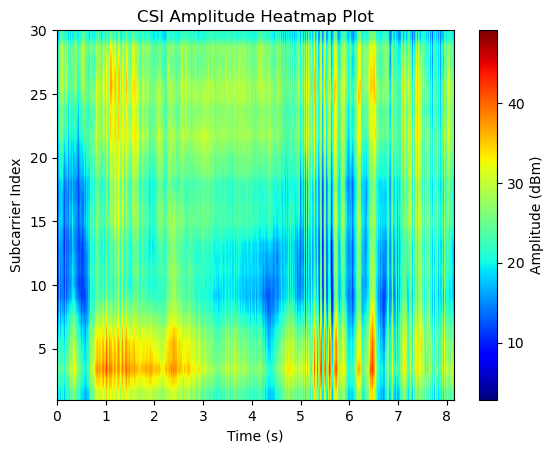

(47+4j)


In [12]:
from CSIKit.tools.batch_graph import BatchGraph

csi_matrix_first = csi_matrix1[:, :, 0, 0]
print(np.max(csi_matrix_first))
csi_matrix_squeezed = np.abs(np.squeeze(csi_matrix_first))
BatchGraph.plot_heatmap(csi_matrix_squeezed, csi_data.timestamps)
print(np.max(csi_matrix_first))


In [13]:
# Preprocessing the csi matrix based on the method in Widar3 paper and calculate the motion statistics
from scipy.signal import butter, filtfilt

def nextpow2(i):
    return np.ceil(np.log2(i))
def autocorr(x):
    nFFT = int(2**(nextpow2(len(x))+1))
    F = np.fft.fft(x,nFFT)
    F = F*np.conj(F)
    acf = np.fft.ifft(F)
    acf = acf[0:len(x)] # Retain nonnegative lags
    acf = np.real(acf)
    acf = acf/acf[0] # Normalize
    return acf

def preprocess_CSI(csi_matrix: np.array, csi_sample_rate: int = 1000):
    '''ArithmeticError
    Preprocesses the CSI matrix by applying phase cleaning (Widar3.0) and a lowpass and highpass filter.
    Then, calculates the motion statistics.
    The shape of the CSI matrix (complex-valued) should be Frames (time dimension) * Subcarriers * Rx * Tx.
    Returns the processed CSI matrix and the motion statistics.
    '''
    # define the lowpass and highpass filter
    half_rate = csi_sample_rate / 2
    uppe_orde = 6
    uppe_stop = 60
    if uppe_stop > half_rate:
        uppe_stop = half_rate - 1
    lowe_orde = 3
    lowe_stop = 2
    lu, ld = butter(uppe_orde, uppe_stop / half_rate, 'low')  
    hu, hd = butter(lowe_orde, lowe_stop / half_rate, 'high')
    
    num_frames, num_subcarriers, num_rx, num_tx = csi_matrix.shape
    print("num_frames: ", num_frames)
    print("num_subcarriers: ", num_subcarriers)
    print("num_rx: ", num_rx)
    print("num_tx: ", num_tx)
    # phase cleaning
    if num_rx == 1:
        cleaned_csi = csi_matrix
    elif num_rx == 2:
        cleaned_csi = np.zeros((num_frames, num_subcarriers, 1, num_tx), dtype=complex)
        cleaned_csi = csi_matrix[:, :, 0, :] * np.conj(csi_matrix[:, :, 1, :])
    else:
        cleaned_csi = np.zeros((num_frames, num_subcarriers, num_rx, num_tx), dtype=complex)
        for i in range(num_rx):
            cleaned_csi[:, :, i, :] = csi_matrix[:, :, i, :] * np.conj(csi_matrix[:, :, (i + 1)%num_rx, :])

    # calculate the motion statistics
    
    # print("csi shape")
    # for sliding window size = 500, step = 100,
    win_start = list(range(0, num_frames-100, 100))
    win_num = len(win_start)
    motion_statistics = np.zeros((win_num, num_subcarriers, num_rx, num_tx))
    for ti, w_start in enumerate(win_start):
        for j in range(num_rx):
            for k in range(num_tx):
                win_range = range(w_start, w_start+100)
                csi_jk = cleaned_csi[win_range, :, j, k].copy()
                csi_jk_amp = np.abs(csi_jk)
                # L2 norm across subcarriers
                time_len = csi_jk_amp.shape[0]
                csi_jk_norm = [csi_jk_amp[t, :] / np.linalg.norm(csi_jk_amp[t, :]) for t in range(time_len)]
                csi_jk_norm = np.array(csi_jk_norm)
                # print("csi_jk_norm shape: ", csi_jk_norm.shape)
                # Remove DC
                for i in range(num_subcarriers):
                    this_csi = csi_jk_norm[:, i]
                    # remove DC
                    this_csi = this_csi - np.mean(this_csi)
                    this_acf = autocorr(this_csi)
                    motion_statistics[ti, i, j, k] = this_acf[1]
                    
     # apply the lowpass filter
    for i in range(num_subcarriers):
        for j in range(num_rx):
            for k in range(num_tx):
                cleaned_csi[:, i, j, k] = filtfilt(lu, ld, cleaned_csi[:, i, j, k])
    # apply the highpass filter
    for i in range(num_subcarriers):
        for j in range(num_rx):
            for k in range(num_tx):
                cleaned_csi[:, i, j, k] = filtfilt(lu, ld, cleaned_csi[:, i, j, k])

    return cleaned_csi, motion_statistics

num_frames:  8143
num_subcarriers:  30
num_rx:  3
num_tx:  1
cleaned_csi:  (8143, 30, 3, 1)
motion_statistics:  (81, 30, 3, 1)
(416.1765905045714-432.99748008850895j)


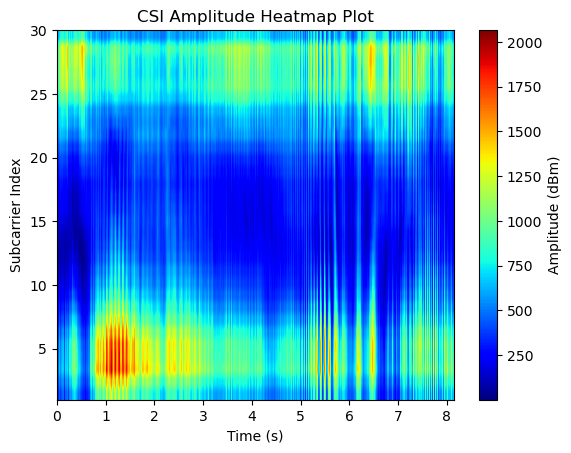

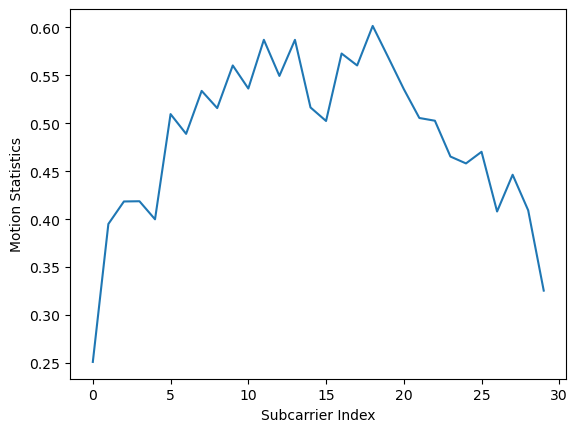

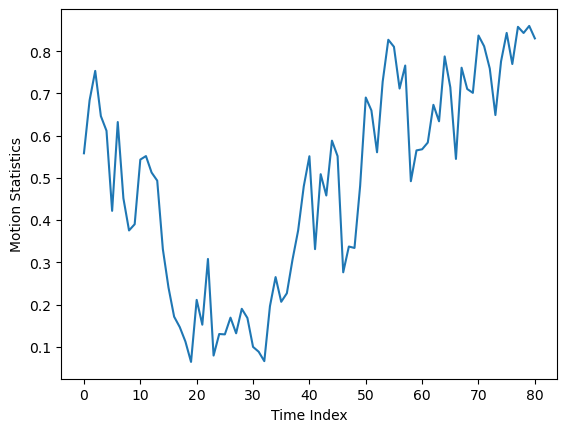

In [17]:
cleaned_csi, motion_statistics = preprocess_CSI(csi_matrix1)

print("cleaned_csi: ", cleaned_csi.shape)
print("motion_statistics: ", motion_statistics.shape)

csi_matrix_first = cleaned_csi[:, :, 0, 0]
csi_matrix_squeezed = np.abs(np.squeeze(csi_matrix_first))
print(np.max(csi_matrix_first))
BatchGraph.plot_heatmap(csi_matrix_squeezed, csi_data.timestamps)

motion_s = motion_statistics[:, :, 0, 0]
ms_time = np.mean(motion_s, axis=1)
ms_subcarrier = np.mean(motion_s, axis=0)
import matplotlib.pyplot as plt
plt.plot(ms_subcarrier)
plt.xlabel('Subcarrier Index')
plt.ylabel('Motion Statistics')
plt.show()

plt.plot(ms_time)
plt.xlabel('Time Index')
plt.ylabel('Motion Statistics')
plt.show()


## Check the time length of the instances in the dataset

In [1]:
# load the metas.csv file
import pandas as pd
df = pd.read_csv('metas.csv')
print(df.head())


                          file_name  user_id  track_id  rep_id  rx_id
0   20190707/user1/user1-5-3-r5.dat        1         5       3      5
1  20190707/user1/user1-5-12-r1.dat        1         5      12      1
2  20190707/user1/user1-6-13-r3.dat        1         6      13      3
3   20190707/user1/user1-6-9-r6.dat        1         6       9      6
4   20190707/user1/user1-6-2-r6.dat        1         6       2      6


In [2]:
file_names = df['file_name'].values
print("The number of instances: ", len(file_names))

The number of instances:  22528


In [1]:
from CSIKit.reader import IWLBeamformReader
import pickle
from tqdm import tqdm

import itertools
from typing import Tuple
import numpy as np

def get_CSI(csi_data: 'CSIData', squeeze_output: bool = False) -> Tuple[np.array, int, int]:
    frames = csi_data.frames
    csi_shape = frames[0].csi_matrix.shape

    no_frames = len(frames)
    no_subcarriers = csi_shape[0]

    # Matrices should be Frames * Subcarriers * Rx * Tx.
    # Single Rx/Tx streams should be squeezed.
    if len(csi_shape) == 3:
        # Intel data comes as Subcarriers * Rx * Tx.
        no_rx_antennas = csi_shape[1]
        no_tx_antennas = csi_shape[2]
    elif len(csi_shape) == 2 or len(csi_shape) == 1:
        # Single antenna stream.
        no_rx_antennas = 1
        no_tx_antennas = 1
    else:
        # Error. Unknown CSI shape.
        print("Error: Unknown CSI shape.")

    csi = np.zeros((no_frames, no_subcarriers, no_rx_antennas, no_tx_antennas), dtype=complex)
    ranges = itertools.product(*[range(n) for n in [no_frames, no_subcarriers, no_rx_antennas, no_tx_antennas]])
    is_single_antenna = no_rx_antennas == 1 and no_tx_antennas == 1

    drop_indices = []
    for frame, subcarrier, rx_antenna_index, tx_antenna_index in ranges:
        frame_data = frames[frame].csi_matrix
        if subcarrier >= frame_data.shape[0]:
            # Inhomogenous component
            # Skip frame for now. Need a better method soon.
            continue

        subcarrier_data = frame_data[subcarrier]
        if subcarrier_data.shape != (no_rx_antennas, no_tx_antennas) and not is_single_antenna:
            if rx_antenna_index >= subcarrier_data.shape[0] or tx_antenna_index >= subcarrier_data.shape[1]:
                # Inhomogenous component
                # Skip frame for now. Need a better method soon.
                drop_indices.append(frame)
                continue
        csi[frame][subcarrier][rx_antenna_index][tx_antenna_index] = subcarrier_data if is_single_antenna else \
            subcarrier_data[rx_antenna_index][tx_antenna_index]  
    csi = np.delete(csi, drop_indices, 0)
    csi_data.timestamps = [x for i, x in enumerate(csi_data.timestamps) if i not in drop_indices]
    if squeeze_output:
        csi = np.squeeze(csi)
    return (csi, no_frames, no_subcarriers)



# my_reader = IWLBeamformReader()

# # check the time length of the csi data and add to the df, then save as a new csv file
# time_lengths = []
# for fn in tqdm(file_names):
#     csi_data = my_reader.read_file(fn)
#     csi_matrix, _, _ = get_CSI(csi_data)
#     time_length = csi_matrix.shape[0]
#     # print("time_length: ", time_length)
#     df.loc[df['file_name'] == fn, 'time_length'] = time_length
#     time_lengths.append(time_length)

# # save the new df as a csv file
# df.to_csv('metas2.csv', index=False)


In [10]:
import pandas as pd

class loading_csi_data:
    def __init__(self, file_name_list):
        self.file_name = file_name_list
        self.my_reader = IWLBeamformReader()
        print("The number of instances: ", len(file_name_list))


    def load_csi_data(self, indexes):
        start_index, end_index = indexes
        loading_files = self.file_name[start_index:end_index]
        csi_data_list = []
        csi_data_len_list = []
        for file_name in loading_files:
            csi_data = my_reader.read_file(file_name)
            csi_matrix, _, _ = get_CSI(csi_data)
            csi_data_list.append(csi_matrix)
            csi_data_len_list.append(csi_matrix.shape[0])
        return csi_data_list, csi_data_len_list
    
    def get_len(self):
        return len(self.file_name)
        

# read the metas.csv file
df = pd.read_csv('metas.csv')
print(df.head())
file_names = df['file_name'].values
print("The number of instances: ", len(file_names))

csi_loader = loading_csi_data(file_names)
num_files = csi_loader.get_len()

# split the data into 100 parts
num_processes = 100
b = []
for i in range(num_processes):
    start_index = i * num_files // num_processes
    end_index = (i + 1) * num_files // num_processes
    b.append((start_index, end_index))
    
print(b)

                          file_name  user_id  track_id  rep_id  rx_id
0   20190707/user1/user1-5-3-r5.dat        1         5       3      5
1  20190707/user1/user1-5-12-r1.dat        1         5      12      1
2  20190707/user1/user1-6-13-r3.dat        1         6      13      3
3   20190707/user1/user1-6-9-r6.dat        1         6       9      6
4   20190707/user1/user1-6-2-r6.dat        1         6       2      6
The number of instances:  22528
The number of instances:  22528
[(0, 225), (225, 450), (450, 675), (675, 901), (901, 1126), (1126, 1351), (1351, 1576), (1576, 1802), (1802, 2027), (2027, 2252), (2252, 2478), (2478, 2703), (2703, 2928), (2928, 3153), (3153, 3379), (3379, 3604), (3604, 3829), (3829, 4055), (4055, 4280), (4280, 4505), (4505, 4730), (4730, 4956), (4956, 5181), (5181, 5406), (5406, 5632), (5632, 5857), (5857, 6082), (6082, 6307), (6307, 6533), (6533, 6758), (6758, 6983), (6983, 7208), (7208, 7434), (7434, 7659), (7659, 7884), (7884, 8110), (8110, 8335), (8335, 8

### Time length of the instances

After excuting the preparing_dataset.py, we can get the time_lengths.npy file, which contains the time length of each sample data in the selected data files.

No. processors for time length recording:  (100,)
No. of samples:  (22528,)


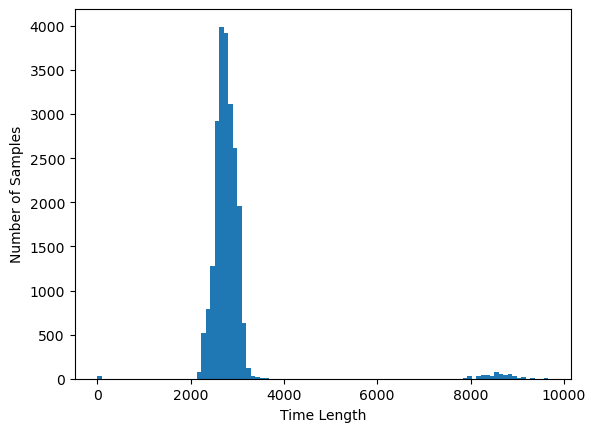

In [1]:
import numpy as np

# loading the time_lengths.npy file
time_lengths = np.load('time_lengths.npy', allow_pickle=True)
print('No. processors for time length recording: ', time_lengths.shape)

ts_list = []
for ts in time_lengths:
    ts_list.extend(ts)

ts_np = np.array(ts_list)
print('No. of samples: ', ts_np.shape)


# visualize the time_lengths histogram
import matplotlib.pyplot as plt
plt.hist(ts_np, bins=100)
plt.xlabel('Time Length')
plt.ylabel('Number of Samples')
plt.show()

## Packing the data and preparing the preprocessed csi and dfs for later use

In [1]:
import os
CSI_folders = os.listdir('CSI')
print(CSI_folders)

['20190706', '20190718', '20190627', '20190713', '20190719', '20190707']


The above folders contain the raw csi data is now in the CSI/ foder. We then run the save_preprocessed_csi.py to generate the preprocessed data and the dfs data, all stored in the CSI-Processed/ and DFS/ folders.


The following is a visualization of the DFS data.

(263, 121, 30, 3, 2)
float32
(263, 121, 30, 3)


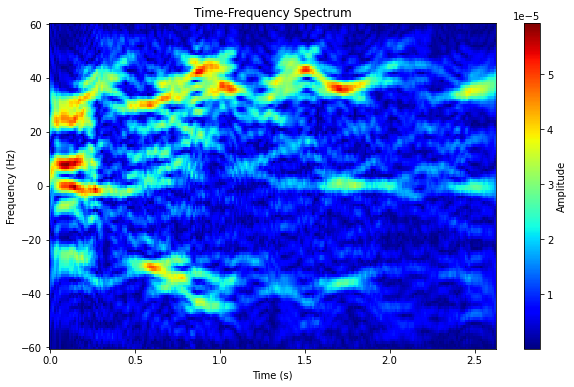

In [1]:
import matplotlib.pyplot as plt
import numpy as np

csi_matrix = np.load('DFS/20190707/user4/user4-1-1-r1.npy')
print(csi_matrix.shape)  # shape: (frames (Time bins), freq_bins, subcarriers, Rx*Tx, 2)
# convert to float16
print(csi_matrix.dtype)

magnitude = np.sqrt(csi_matrix[..., 0]**2 + csi_matrix[..., 1]**2)  # Calculate magnitude from real and imaginary parts
print(magnitude.shape)
ticks = np.arange(0.0, csi_matrix.shape[0] / 100, 0.01)
freq_bin = np.arange(-60, 61, 1)

plt.figure(figsize=(10, 6))
plt.pcolormesh(ticks, freq_bin, magnitude[:,:,2,0].T, shading='auto', cmap='jet')
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Time-Frequency Spectrum')
plt.show()

## Final directory structure

```shell
.
├── CSI                         # the raw csi data
├── CSI_Processed               # the preprocessed csi data
├── DFS                         # the doppler frequency shift spectrum of the preprocessed csi data
├── metas.csv                   # the meta information of the dataset
├── preparing_dataset.py        # the script to prepare the dataset: generate the time_lengths.npy file
├── preprocessing_log.txt       # the log file of the preprocessing process
├── README_Gait.pdf             # the official document of the dataset 
├── README.ipynb
├── save_preprocessed_csi.py    # the script to generate the preprocessed csi and dfs data
└── time_lengths.npy            # the time length of each sample data (raw data)
```
